In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tqdm import tqdm

In [3]:
# --- 1. Configuration ---
# --- MODIFIED: Set a local file path ---
CLEANED_DATA_PATH = "cleaned_csi_data.csv" 
# --- ADDED: Fraction of data to use for local training ---
SAMPLE_FRACTION = 0.3 
PCA_COMPONENTS = 50
TEST_SIZE = 0.2
VALIDATION_SPLIT = 0.2
EPOCHS = 50 
BATCH_SIZE = 32
USE_PCA = True
USE_MAGNITUDE = True

In [5]:
# --- 2. Load and Prepare Data (Timestamp Grouping Method) ---
print("Loading and preparing data...")
try:
    df = pd.read_csv(CLEANED_DATA_PATH)
    print("Data loaded successfully.")
except FileNotFoundError:
    print(f"Error: The file {CLEANED_DATA_PATH} was not found.")
    exit()

data, labels = [], []
grouped = df.groupby(["session", "timestamp"])

for (session, ts), group in tqdm(grouped, desc="Processing Timestamps"):
    if USE_MAGNITUDE:
        features = group["magnitude"].values
    else:
        features = group[["I", "Q"]].values.flatten()
    
    if len(features) > 0:
        label = group["activity"].iloc[0]
        data.append(features)
        labels.append(label)

X_padded = tf.keras.preprocessing.sequence.pad_sequences(data, padding='post', dtype='float32')
y = np.array(labels)

print(f"\nFull processed data shape (X): {X_padded.shape}")
print(f"Full processed labels shape (y): {y.shape}")

Loading and preparing data...
Data loaded successfully.


Processing Timestamps: 100%|█████████████████████████████████████████████████| 201597/201597 [00:28<00:00, 7075.71it/s]



Full processed data shape (X): (201597, 117)
Full processed labels shape (y): (201597,)


In [7]:
# --- 3. Subsample Data for Local Training ---
if SAMPLE_FRACTION < 1.0:
    print(f"\nSubsampling data to {SAMPLE_FRACTION*100:.0f}% of original size for local training...")
    # Use train_test_split to get a stratified random sample. We only need the first part.
    X_padded, _, y, _ = train_test_split(
        X_padded, y, 
        train_size=SAMPLE_FRACTION, 
        random_state=42, 
        stratify=y
    )
    print(f"New data shape (X): {X_padded.shape}")
    print(f"New labels shape (y): {y.shape}")


Subsampling data to 30% of original size for local training...
New data shape (X): (60479, 117)
New labels shape (y): (60479,)


In [9]:
# --- 4. Encode Labels and Split Data ---
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)
print(f"\nLabel mapping: { {i: label for i, label in enumerate(class_names)} }")

X_train, X_test, y_train, y_test = train_test_split(
    X_padded, y_enc, test_size=TEST_SIZE, random_state=42, stratify=y_enc
)


Label mapping: {0: 'falling', 1: 'sitting', 2: 'sleeping', 3: 'standing', 4: 'walking'}


In [11]:
# --- 5. Apply PCA (Optional) ---
if USE_PCA:
    print(f"\nApplying PCA, reducing features to {PCA_COMPONENTS} components...")
    n_components = min(PCA_COMPONENTS, X_train.shape[1])
    pca = PCA(n_components=n_components)
    X_train = pca.fit_transform(X_train)
    X_test = pca.transform(X_test)
    print(f"Shape after PCA (X_train): {X_train.shape}")

input_shape = (X_train.shape[1],)


Applying PCA, reducing features to 50 components...
Shape after PCA (X_train): (48383, 50)


In [15]:
# --- 6. Model Definition (TensorFlow/Keras) ---
def build_cnn_lstm(input_shape, num_classes):
    model = models.Sequential([
        # --- MODIFIED: Added Input layer to resolve warning ---
        layers.Input(shape=input_shape),
        layers.Reshape((input_shape[0], 1)),
        layers.Conv1D(64, 3, activation='relu'),
        layers.MaxPooling1D(2),
        layers.LSTM(64),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_cnn_lstm(input_shape, num_classes=len(class_names))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)                  │ (None, 50, 1)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 48, 64)              │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 24, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 37,765 (147.52 KB)

 Trainable params: 37,765 (147.52 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# --- 7. Train the Model ---
print("\nStarting model training...")
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=VALIDATION_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=2
)


Starting model training...
Epoch 1/50
1210/1210 - 35s - 29ms/step - accuracy: 0.4680 - loss: 1.1856 - val_accuracy: 0.5785 - val_loss: 0.9591
Epoch 2/50
1210/1210 - 46s - 38ms/step - accuracy: 0.5917 - loss: 0.9328 - val_accuracy: 0.6028 - val_loss: 0.9071
Epoch 3/50
1210/1210 - 53s - 44ms/step - accuracy: 0.6301 - loss: 0.8611 - val_accuracy: 0.6488 - val_loss: 0.8240
Epoch 4/50
1210/1210 - 41s - 34ms/step - accuracy: 0.6578 - loss: 0.8102 - val_accuracy: 0.6773 - val_loss: 0.7742
Epoch 5/50
1210/1210 - 36s - 30ms/step - accuracy: 0.6804 - loss: 0.7657 - val_accuracy: 0.6742 - val_loss: 0.7757
Epoch 6/50
1210/1210 - 27s - 23ms/step - accuracy: 0.6960 - loss: 0.7350 - val_accuracy: 0.7093 - val_loss: 0.7044
Epoch 7/50
1210/1210 - 29s - 24ms/step - accuracy: 0.7108 - loss: 0.7033 - val_accuracy: 0.6995 - val_loss: 0.7412
Epoch 8/50
1210/1210 - 44s - 37ms/step - accuracy: 0.7229 - loss: 0.6783 - val_accuracy: 0.7186 - val_loss: 0.7015
Epoch 9/50
1210/1210 - 77s - 64ms/step - accuracy: 0


Evaluating model performance...


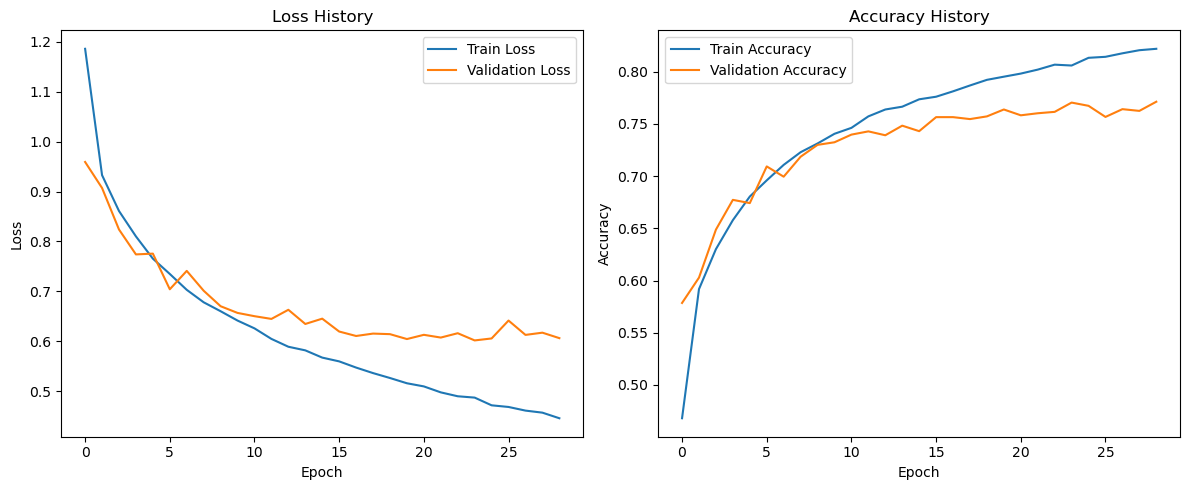

378/378 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step


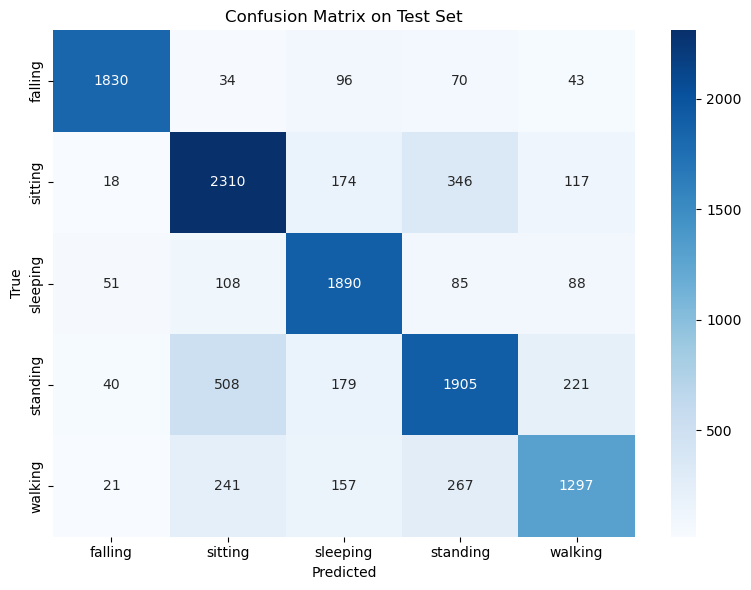


Classification Report:

              precision    recall  f1-score   support

     falling       0.93      0.88      0.91      2073
     sitting       0.72      0.78      0.75      2965
    sleeping       0.76      0.85      0.80      2222
    standing       0.71      0.67      0.69      2853
     walking       0.73      0.65      0.69      1983

    accuracy                           0.76     12096
   macro avg       0.77      0.77      0.77     12096
weighted avg       0.76      0.76      0.76     12096



In [19]:
# --- 8. Evaluate the Model ---
print("\nEvaluating model performance...")

# --- Plot training history ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# --- Confusion Matrix and Report ---
preds = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix on Test Set")
plt.tight_layout()
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, preds, target_names=class_names))